# Graph Neural Networks (GNNs)

## 1. Graph Basics

A graph $G = (V, E)$ consists of:
- **Nodes** $V$: entities with feature vectors $\mathbf{x}_v \in \mathbb{R}^d$
- **Edges** $E$: relationships, possibly with features
- **Adjacency matrix** $A \in \{0,1\}^{|V|\times|V|}$: $A_{ij}=1$ if $(i,j) \in E$
- **Degree matrix** $D$: diagonal, $D_{ii} = \sum_j A_{ij}$

### Graph Types
- **Directed / Undirected**: asymmetric / symmetric $A$
- **Homogeneous / Heterogeneous**: single / multiple node/edge types
- **Temporal**: edges change over time
- **Attributed**: nodes/edges have features

### Tasks
- **Node classification**: predict label for each node
- **Link prediction**: predict missing edges
- **Graph classification**: classify entire graphs
- **Graph generation**: generate new graphs

## 2. Message Passing Framework

The general GNN layer:
$$\mathbf{m}_v^{(l)} = \text{AGGREGATE}\left(\{\mathbf{h}_u^{(l-1)} : u \in \mathcal{N}(v)\}\right)$$
$$\mathbf{h}_v^{(l)} = \text{UPDATE}\left(\mathbf{h}_v^{(l-1)}, \mathbf{m}_v^{(l)}\right)$$

After $L$ layers, each node representation aggregates information from its $L$-hop neighborhood.

## 3. Graph Convolutional Network (GCN)

Kipf & Welling (2017). Spectral convolution simplified to:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)}\right)$$

where $\tilde{A} = A + I$ (add self-loops), $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$.

**Layer-wise propagation rule:**
$$\mathbf{h}_v^{(l+1)} = \sigma\left(W^{(l)} \cdot \frac{1}{|\mathcal{N}(v)|+1} \sum_{u \in \mathcal{N}(v) \cup \{v\}} \mathbf{h}_u^{(l)}\right)$$

Essentially: **mean aggregation** of neighbors + self, followed by linear transformation.

## 4. GraphSAGE

Hamilton et al. (2017). **Inductive** learning (generalizes to unseen nodes):
$$\mathbf{h}_{\mathcal{N}(v)}^{(l)} = \text{AGGREGATE}_l\left(\{\mathbf{h}_u^{(l-1)} : u \in \mathcal{N}(v)\}\right)$$
$$\mathbf{h}_v^{(l)} = \sigma\left(W^{(l)} \cdot \text{CONCAT}\left(\mathbf{h}_v^{(l-1)}, \mathbf{h}_{\mathcal{N}(v)}^{(l)}\right)\right)$$

Aggregators: mean, LSTM, max pooling.

## 5. Graph Attention Network (GAT)

Veličković et al. (2018). Learns to attend to different neighbors:

$$e_{ij} = \text{LeakyReLU}\left(\mathbf{a}^T [W\mathbf{h}_i \| W\mathbf{h}_j]\right)$$
$$\alpha_{ij} = \text{softmax}_j(e_{ij}) = \frac{\exp(e_{ij})}{\sum_{k \in \mathcal{N}(i)} \exp(e_{ik})}$$
$$\mathbf{h}_i' = \sigma\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij} W\mathbf{h}_j\right)$$

Multi-head attention:
$$\mathbf{h}_i' = \|_{k=1}^K \sigma\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij}^k W^k \mathbf{h}_j\right)$$

## 6. Graph Isomorphism Network (GIN)

Xu et al. (2019). **Most expressive** GNN (as powerful as Weisfeiler-Leman test):
$$\mathbf{h}_v^{(l)} = \text{MLP}^{(l)}\left((1 + \epsilon^{(l)}) \cdot \mathbf{h}_v^{(l-1)} + \sum_{u \in \mathcal{N}(v)} \mathbf{h}_u^{(l-1)}\right)$$

## 7. Graph Transformers
Apply full attention over all node pairs:
$$\mathbf{h}_i' = \sum_{j} \text{softmax}\left(\frac{(\mathbf{h}_i W_Q)(\mathbf{h}_j W_K)^T}{\sqrt{d}}\right) \mathbf{h}_j W_V$$

Examples: Graphormer, GPS, SAN.

GCN Accuracy on Karate Club: 1.0000


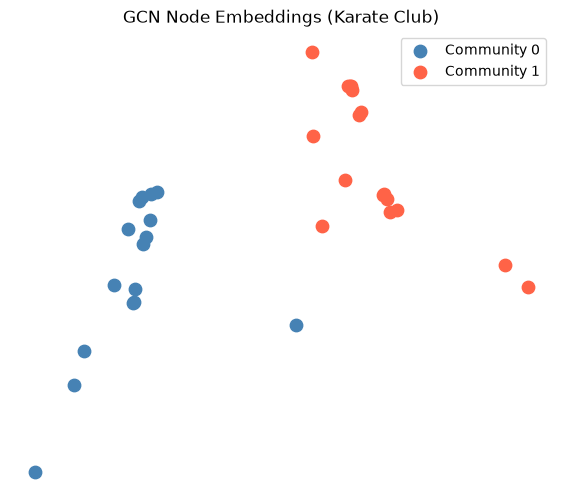

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GCN from Scratch (without PyTorch Geometric)
# ============================================================

class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)

    def normalize_adj(self, A):
        A_tilde = A + torch.eye(A.size(0), device=A.device)
        D = A_tilde.sum(1)
        D_inv_sqrt = torch.diag(D.pow(-0.5))
        return D_inv_sqrt @ A_tilde @ D_inv_sqrt

    def forward(self, X, A):
        A_norm = self.normalize_adj(A)
        return F.relu(A_norm @ self.W(X))


class GCN(nn.Module):
    def __init__(self, in_features, hidden, num_classes, dropout=0.5):
        super().__init__()
        self.layer1 = GCNLayer(in_features, hidden)
        self.layer2 = GCNLayer(hidden, num_classes)
        self.drop = nn.Dropout(dropout)

    def forward(self, X, A):
        h = self.drop(self.layer1(X, A))
        return self.layer2(h, A)  # logits


# ---- GAT Layer from scratch ----
class GATLayer(nn.Module):
    def __init__(self, in_features, out_features, alpha=0.2):
        super().__init__()
        self.W  = nn.Linear(in_features, out_features, bias=False)
        self.a  = nn.Linear(2 * out_features, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(alpha)

    def forward(self, X, A):
        N = X.size(0)
        Wh = self.W(X)  # (N, out)
        # Compute attention coefficients
        Wh_i = Wh.unsqueeze(1).expand(-1, N, -1)   # (N, N, out)
        Wh_j = Wh.unsqueeze(0).expand(N, -1, -1)   # (N, N, out)
        concat = torch.cat([Wh_i, Wh_j], dim=-1)   # (N, N, 2*out)
        e = self.leaky_relu(self.a(concat)).squeeze(-1)  # (N, N)
        # Mask non-neighbors
        mask = (A > 0) | torch.eye(N, dtype=torch.bool, device=A.device)
        e = e.masked_fill(~mask, float('-inf'))
        alpha = F.softmax(e, dim=1)  # attention weights
        return F.elu(torch.matmul(alpha, Wh))


# ---- Karate Club Graph demo ----
# Zachary's Karate Club: 34 nodes, 2 communities
# Build adjacency from edge list
edges = [
    (0,1),(0,2),(0,3),(0,4),(0,5),(0,6),(0,7),(0,8),(0,10),(0,11),(0,12),(0,13),
    (0,17),(0,19),(0,21),(0,31),(1,2),(1,3),(1,7),(1,13),(1,17),(1,19),(1,21),(1,30),
    (2,3),(2,7),(2,8),(2,9),(2,13),(2,27),(2,28),(2,32),(3,7),(3,12),(3,13),(4,6),
    (4,10),(5,6),(5,10),(5,16),(6,16),(8,30),(8,32),(8,33),(9,33),(13,33),(14,32),
    (14,33),(15,32),(15,33),(18,32),(18,33),(19,33),(20,32),(20,33),(22,32),(22,33),
    (23,25),(23,27),(23,29),(23,32),(23,33),(24,25),(24,27),(24,31),(25,31),(26,29),
    (26,33),(27,33),(28,31),(28,33),(29,32),(29,33),(30,32),(30,33),(31,32),(31,33),(32,33)
]
N = 34
A = torch.zeros(N, N)
for i, j in edges:
    A[i,j] = A[j,i] = 1.0

# Node features: degree one-hot-like + random
X = torch.eye(N)  # identity features
# Labels: 2 communities (0 or 1)
y = torch.tensor([0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1])

# Train GCN
gcn = GCN(N, 16, 2, dropout=0.0)
opt = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)

for ep in range(200):
    gcn.train()
    logits = gcn(X, A)
    loss = F.cross_entropy(logits, y)
    opt.zero_grad(); loss.backward(); opt.step()

gcn.eval()
with torch.no_grad():
    pred = gcn(X, A).argmax(1)
acc = (pred == y).float().mean().item()
print(f'GCN Accuracy on Karate Club: {acc:.4f}')

# Visualize learned embeddings
with torch.no_grad():
    layer1_out = gcn.layer1(X, A).numpy()
from sklearn.manifold import TSNE
emb = TSNE(n_components=2, random_state=42).fit_transform(layer1_out)
plt.figure(figsize=(7,6))
colors = ['steelblue','tomato']
for cls in [0,1]:
    mask = y.numpy() == cls
    plt.scatter(emb[mask,0], emb[mask,1], c=colors[cls], s=80, label=f'Community {cls}')
plt.title('GCN Node Embeddings (Karate Club)')
plt.legend(); plt.axis('off'); plt.show()

## Additional Learning Resources

### Key Papers
- **GCN** (Kipf & Welling, 2017): https://arxiv.org/abs/1609.02907
- **GraphSAGE** (Hamilton et al., 2017): https://arxiv.org/abs/1706.02216
- **GAT** (Veličković et al., 2018): https://arxiv.org/abs/1710.10903
- **GIN** (Xu et al., 2019): https://arxiv.org/abs/1810.00826
- **GATv2** (Brody et al., 2022): https://arxiv.org/abs/2105.14491
- **Graphormer** (Ying et al., 2021): https://arxiv.org/abs/2106.05234

### Tutorials & Courses
- **CS224W: Machine Learning with Graphs** Stanford: http://web.stanford.edu/class/cs224w/
- **PyTorch Geometric Documentation**: https://pytorch-geometric.readthedocs.io/
- **Deep Graph Library (DGL)**: https://www.dgl.ai/
- **Distill: A Gentle Introduction to GNNs**: https://distill.pub/2021/gnn-intro/

### Survey
- **A Comprehensive Study on GNNs** (Wu et al., 2019): https://arxiv.org/abs/1901.00596